# Double working precision in PyCBC: replaying recorded H1 inputs

PyCBC tests a candidate gravitational-wave signal's consistency across frequency bins. With complex64 correlations, its selected-point CPU chi-square routine repeatedly rounds rotations and sums to float32. This notebook compares the original implementation with a change that uses double working precision while retaining complex64 inputs and float32 outputs.

The inputs are all three samples from one saved call in a search of public LIGO Hanford (H1) strain: 2048 Hz, a 512-second segment, 16 chi-square bins and 32 IMRPhenomD templates. This call had the largest discrepancy among six saved calls (11 samples). **It is a diagnostic example, not a representative estimate of search impact.** Conditioning, correlation, bin edges, SNR and normalization stay fixed. The CPU routine being tested performs no FFT.

## Setup

Run from this directory with PyCBC, NumPy, SciPy, pandas, Matplotlib, Cython, Jupyter and a C++ compiler installed. Keep `cpu_chisq_review.py`, `kernels/manifest.json`, `kernels/upstream.pyx`, `kernels/arithmetic.pyx`, `arithmetic_benchmark.csv`, and `../data/point-input-05.npz` alongside the notebook at their shown paths. **Restart Kernel and Run All**. The helper builds only these two Cython implementations with PyCBC's build flags. [Capture provenance](../data/point-input-05.json).

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio:")

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import ifft
from pycbc.types import Array
from pycbc.events.ranking import newsnr
from cpu_chisq_review import kernels, load_capture, reference_power, plot_style

plot_style()
modules = kernels(("upstream", "arithmetic"))
data = load_capture()
corr, snr = data['corr'], data['snr']
points, bins = data['indices'], data['bins']
norm = float(data['norm'])
N, p = len(corr), len(bins) - 1
snr_power = (snr.conj() * snr).real
manifest = json.loads(Path('kernels/manifest.json').read_text())
print('Upstream source:', manifest['upstream_commit'])
print('Samples:', points.tolist(), '; widest bin:', int(np.diff(bins).max()))
assert np.array_equal(points, points.astype(np.float32).astype(points.dtype))
print('All captured indices are exactly representable as float32.')

Upstream source: 454ee900e6faca88a066e71ade489fca9fb221a5
Samples: [484954, 619888, 656106] ; widest bin: 373308
All captured indices are exactly representable as float32.


## Independent reference and actual before/after results

Let qᵦ be the rotated sum in bin b, S = Σᵦ|qᵦ|², and p the number of bins. The statistic is **χ² = (p S − |snr|²) × norm²**. Here `snr` is the captured unnormalized matched-filter sum and `norm` its SNR normalization. The reference evaluates every phase explicitly in complex128 and checks against separate complex128 inverse FFTs. Both preserve the captured SNR-power term, so this evaluates the selected-point stage, not every source of numerical error in a search.

The patch results below retain the actual float32 output and final wrapper arithmetic for complex64 inputs. `verify_installed.py` checked these expressions and archived-kernel outputs against the original and patched public PyCBC calls.

In [2]:
reference = reference_power(corr, points, bins)
fft_power = np.zeros(len(points))
for lo, hi in zip(bins[:-1], bins[1:]):
    band = np.zeros(N, dtype=np.complex128)
    band[lo:hi] = corr[lo:hi]
    fft_power += abs((N * ifft(band))[points])**2
np.testing.assert_allclose(reference, fft_power, rtol=1e-11)
reference_chisq = (p * reference - snr_power) * norm**2
value = Array(corr, copy=False)
powers = {label: module.shift_sum(value, points, bins)
          for label, module in modules.items()}
chisq = {label: (p * power - snr_power) * norm**2
         for label, power in powers.items()}
errors = {label: 100 * (chi / reference_chisq - 1)
          for label, chi in chisq.items()}
np.testing.assert_allclose(chisq['arithmetic'], reference_chisq, rtol=6e-6)
assert max(abs(errors['arithmetic'])) < max(abs(errors['upstream']))
table = pd.DataFrame(errors, index=points)
table.index.name = 'sample'
table.insert(0, 'reference chi-square', reference_chisq)
print('Remaining columns: signed chi-square error (% of reference).')
display(table.style.format(precision=7))
print('Max |direct / FFT reference difference|:',
      np.max(abs(reference / fft_power - 1)))

Remaining columns: signed chi-square error (% of reference).


,reference chi-square,upstream,arithmetic
sample,,,
484954,33.3259417,-0.0281664,-0.0001679
619888,36.3370953,-0.1503483,-0.0002152
656106,42.9809734,0.1721608,0.0005033


Max |direct / FFT reference difference|: 2.220446049250313e-16


## How error develops across frequency bins

Both curves below use the actual compiled kernels, adding complete bins from left to right for sample 656106, the largest-discrepancy sample in this capture. The y-axis expresses the accumulated bin-power error as a percentage of the **final reference chi-square**; intermediate points are not partial chi-square values. Common float64 final arithmetic isolates error inside the kernel. The table above also includes the public wrapper's float32 rounding.

This comparison measures the effect of the entire change to double working precision. It does not allocate separate shares to rotations and summation: the [phase control](phase.ipynb) and [accumulation controls](accumulation.ipynb) isolate those mechanisms using known-answer inputs.

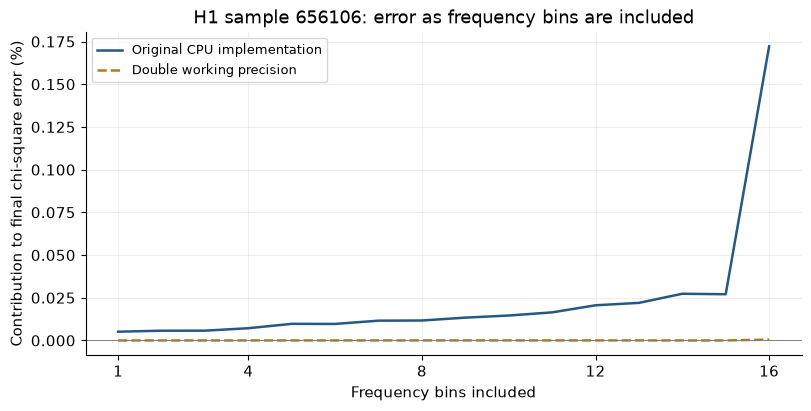

upstream: maximum absolute relative chi-square error = 0.1721608%
arithmetic: maximum absolute relative chi-square error = 0.0005033%


In [3]:
reference_bins = np.array([reference_power(corr, points, bins[j:j+2])
                           for j in range(p)]).T
reference_cumulative = np.cumsum(reference_bins, axis=1)
cumulative = {label: np.column_stack([
    module.shift_sum(value, points, bins[:j+2]) for j in range(p)])
    for label, module in modules.items()}
contribution = {label: 100*p*norm**2*(power-reference_cumulative) /
                reference_chisq[:, None] for label, power in cumulative.items()}
j = int(np.flatnonzero(points == 656106)[0])
x = np.arange(1, p+1)
fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
for label, title, color, style in [
        ('upstream', 'Original CPU implementation', '#245885', '-'),
        ('arithmetic', 'Double working precision', '#B77818', '--')]:
    ax.plot(x, contribution[label][j], label=title, color=color, ls=style)
ax.axhline(0, color='0.5', lw=.7)
ax.set(title='H1 sample 656106: error as frequency bins are included',
       xlabel='Frequency bins included',
       ylabel='Contribution to final chi-square error (%)',
       xticks=[1, 4, 8, 12, 16])
ax.legend(fontsize=9)
plt.show()
for label in modules:
    print(f'{label}: maximum absolute relative chi-square error = '
          f'{max(abs(errors[label])):.7f}%')

## Could candidate selection change?

Chi-square feeds reweighted SNR (NewSNR). Recompute that statistic using the captured SNR and the same threshold of 5. This is an observed per-candidate consequence of the replay, not a sensitivity or false-alarm study. A different near-threshold candidate could change selection if its score moved across the cut; this sample cannot establish how often that happens.

In [4]:
rho = abs(snr) * norm
scores = {label: newsnr(rho, chi / (2*p-2)) for label, chi in chisq.items()}
scores['reference'] = newsnr(rho, reference_chisq / (2*p-2))
selection = pd.DataFrame({
    'SNR': rho, 'upstream NewSNR': scores['upstream'],
    'arithmetic NewSNR': scores['arithmetic'], 'reference NewSNR': scores['reference'],
    'score change': scores['arithmetic'] - scores['upstream'],
    'upstream passes 5': scores['upstream'] >= 5,
    'arithmetic passes 5': scores['arithmetic'] >= 5}, index=points)
selection.index.name = 'sample'
display(selection.style.format(precision=7))
print('Candidates crossing threshold in this replay:',
      np.count_nonzero((scores['upstream'] >= 5) != (scores['arithmetic'] >= 5)))

,SNR,upstream NewSNR,arithmetic NewSNR,reference NewSNR,score change,upstream passes 5,arithmetic passes 5
sample,,,,,,,
484954,5.5250125,5.3710216,5.3705869,5.3705843,-0.0004347,True,True
619888,5.5640130,5.2703499,5.2678191,5.2678154,-0.0025308,True,True
656106,5.5534453,4.9566842,4.9598592,4.9598685,0.0031750,False,False


Candidates crossing threshold in this replay: 0


## CPU cost

The measurements below time the kernel only, excluding input construction, on one macOS arm64 host. Nine interleaved batches give median and interquartile range. The retained measurements compare only the original and double-precision implementations. They do not predict end-to-end search runtime.

[Timings](arithmetic_benchmark.csv) and [environment](arithmetic_benchmark_environment.json) cover short, uniform, captured and wide-bin layouts, complex64/complex128 inputs and 1, 2 and 5 selected samples. Reproduce this comparison with `python benchmark.py --variants upstream arithmetic --output arithmetic_benchmark.csv`.

In [5]:
timings = pd.read_csv('arithmetic_benchmark.csv')
selected = timings[(timings['shape'] == 'captured') &
                   (timings['dtype'] == 'complex64') &
                   timings['variant'].isin(['upstream', 'arithmetic'])]
display(selected[['npoints', 'variant', 'median_ms', 'q25_ms', 'q75_ms',
                  'ratio_to_upstream']].style.format(precision=3))

,npoints,variant,median_ms,q25_ms,q75_ms,ratio_to_upstream
24,1,upstream,1.063,1.039,1.087,1.000
25,1,arithmetic,1.099,1.084,1.121,1.035
26,2,upstream,1.858,1.838,1.926,1.000
27,2,arithmetic,1.168,1.123,1.188,0.628
28,5,upstream,1.746,1.670,1.915,1.000
29,5,arithmetic,2.453,2.434,2.493,1.405


The change reduces the error on these captured samples, and changes their reweighted SNRs, but none crosses the selection threshold. The kernel still uses the constant `3.141592653` when constructing phases, and its output and public wrapper still round to float32; double working precision does not make the full calculation exact. These three selected samples establish neither the prevalence of the discrepancy nor changes in detection efficiency or false-alarm rates.